In [45]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [46]:
low_path = "LOL-v2/train/low"
high_path = "LOL-v2/train/high"

In [47]:
image_names = os.listdir(low_path)

print("Number of images:", len(image_names))
print(image_names[:10])

Number of images: 1589
['img1088.png', 'img469.png', 'img327.png', 'img441.png', 'img455.png', 'img333.png', 'img1077.png', 'img36.png', 'img482.png', 'img496.png']


In [48]:
image_name = image_names[3]

print(image_name)

img441.png


In [49]:
low_img = cv2.imread(os.path.join(low_path, image_name))
high_img = cv2.imread(os.path.join(high_path, image_name))

In [50]:
low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)

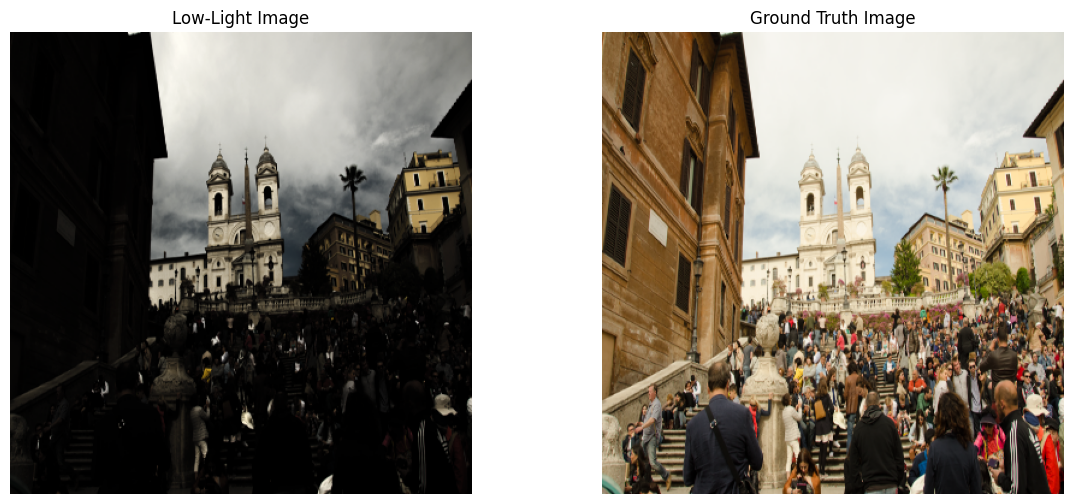

In [51]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(low_img)
plt.title("Low-Light Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(high_img)
plt.title("Ground Truth Image")
plt.axis("off")

plt.show()

In [52]:
print(low_img[100,100])

[4 3 3]


In [53]:
print(high_img[100,100])

[132  96  52]


In [54]:
#  Gray = 0.299R + 0.587G + 0.114B

#  Human eyes are more sensitive to green.

In [55]:
gray_low = cv2.cvtColor(low_img, cv2.COLOR_RGB2GRAY)
gray_high = cv2.cvtColor(high_img, cv2.COLOR_RGB2GRAY)

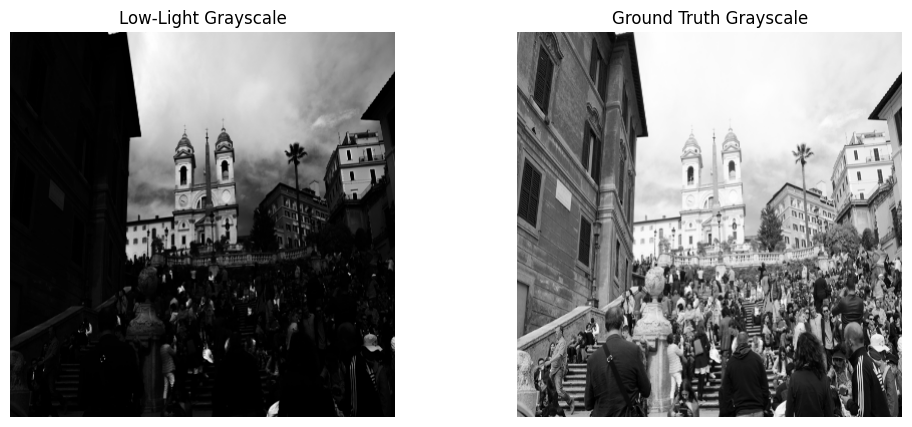

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray_low, cmap='gray')
plt.title("Low-Light Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_high, cmap='gray')
plt.title("Ground Truth Grayscale")
plt.axis("off")

plt.show()

In [57]:
# histogram

# how many pixels exist at each brightness level

# 0   → black
# 255 → white

In [58]:
hist = cv2.calcHist(
    [gray_low],
    [0],
    None,
    [256],
    [0,256]
)

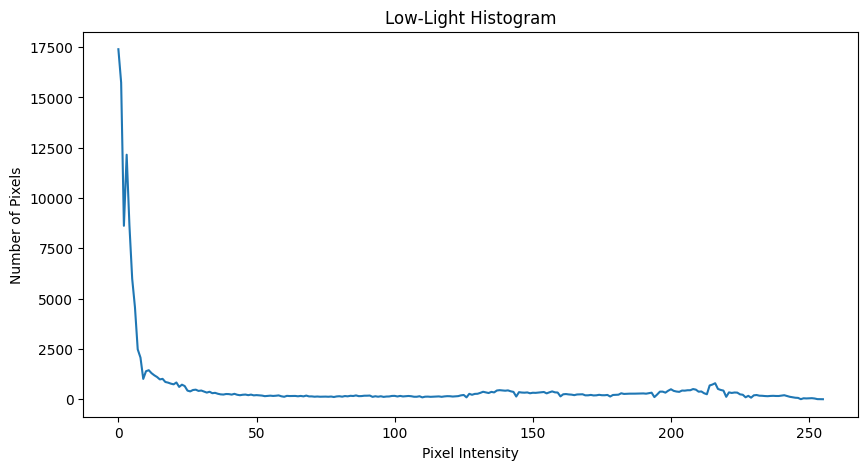

In [59]:
plt.figure(figsize=(10,5))

plt.plot(hist)

plt.title("Low-Light Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.show()

In [60]:
hist = cv2.calcHist(
    [gray_high],
    [0],
    None,
    [256],
    [0,256]
)

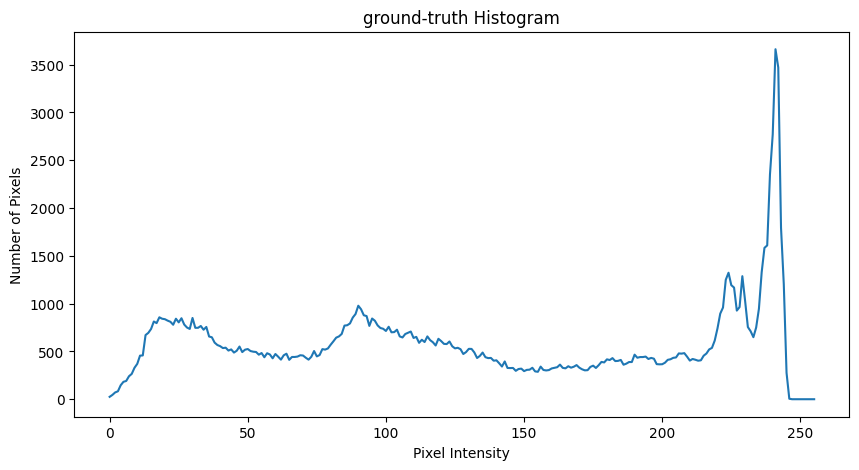

In [61]:
plt.figure(figsize=(10,5))

plt.plot(hist)

plt.title("ground-truth Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")

plt.show()

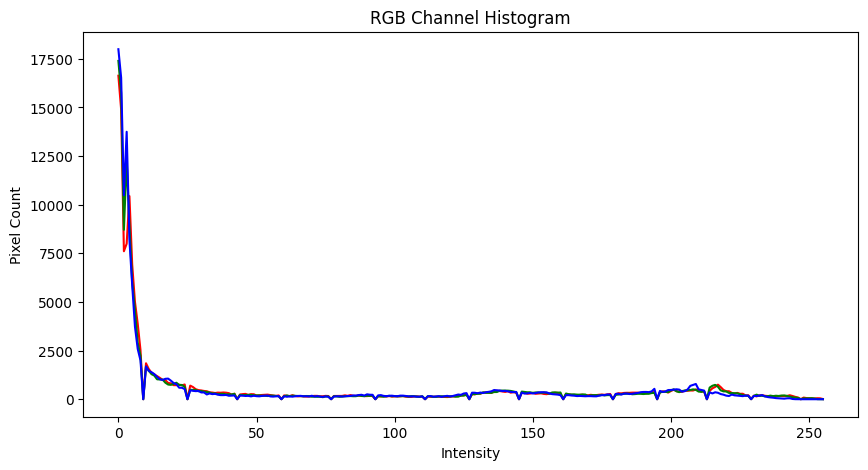

In [62]:
colors = ['r','g','b']

plt.figure(figsize=(10,5))

for i, color in enumerate(colors):

    hist_channel = cv2.calcHist(
        [low_img],
        [i],
        None,
        [256],
        [0,256]
    )

    plt.plot(hist_channel, color=color)

plt.title("RGB Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")

plt.show()

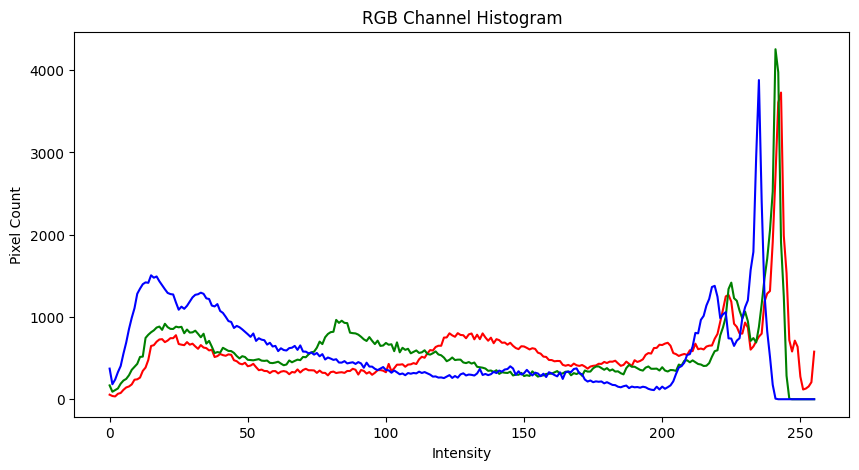

In [63]:
colors = ['r','g','b']

plt.figure(figsize=(10,5))

for i, color in enumerate(colors):

    hist_channel = cv2.calcHist(
        [high_img],
        [i],
        None,
        [256],
        [0,256]
    )

    plt.plot(hist_channel, color=color)

plt.title("RGB Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")

plt.show()

In [64]:
mean_low = np.mean(gray_low)
mean_high = np.mean(gray_high)

print("Low-light mean:", mean_low)
print("Ground truth mean:", mean_high)

Low-light mean: 55.658955891927086
Ground truth mean: 133.8173624674479


In [65]:
std_low = np.std(gray_low)
std_high = np.std(gray_high)

print(std_low)
print(std_high)

77.63731858970097
77.58571807719407


In [66]:
stats = pd.DataFrame({

    "Metric": [
        "Mean Brightness",
        "Std Deviation"
    ],

    "Low-Light": [
        mean_low,
        std_low
    ],

    "Ground Truth": [
        mean_high,
        std_high
    ]

})

stats

,Metric,Low-Light,Ground Truth
0,Mean Brightness,55.658956,133.817362
1,Std Deviation,77.637319,77.585718
